In [1]:
# Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import random
import re
import unicodedata
import time
from collections import Counter, defaultdict

Total pairs loaded: 30000

Sample pairs:
EN: do you see that?
RU: видишь это?

EN: i didn t see it.
RU: я его не видел.

EN: i m a friend.
RU: я друг.

EN: grab this.
RU: ловите это.

EN: women hate tom.
RU: женщины ненавидят тома.

EN — avg: 3.4, max: 6, min: 1
RU — avg: 2.9, max: 9, min: 1


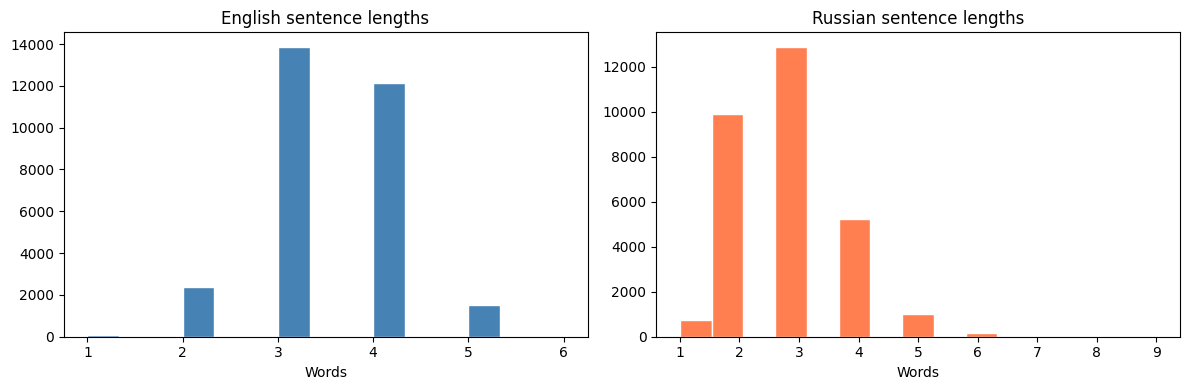

In [3]:
# Load & Explore Data

def unicode_to_ascii(s):
    return ''.join(c for c in unicodedata.normalize('NFD', s)
                   if unicodedata.category(c) != 'Mn')

def clean_en(text):
    text = unicode_to_ascii(text.lower().strip())
    text = re.sub(r"[^a-zA-Z.!?]+", " ", text)
    return text.strip()

def clean_ru(text):
    text = text.lower().strip()
    text = re.sub(r"[^а-яёА-ЯЁ.!?]+", " ", text)
    return text.strip()

def load_data(filepath, max_len=15, num_samples=30000):
    pairs = []
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) < 2:
                continue
            en = clean_en(parts[0])
            ru = clean_ru(parts[1])
            if len(en.split()) <= max_len and len(ru.split()) <= max_len:
                pairs.append((en, ru))
            if len(pairs) >= num_samples:
                break
    random.shuffle(pairs)
    return pairs

pairs = load_data("rus.txt")

print(f"Total pairs loaded: {len(pairs)}")
print(f"\nSample pairs:")
for en, ru in pairs[:5]:
    print(f"EN: {en}")
    print(f"RU: {ru}")
    print()

en_lengths = [len(p[0].split()) for p in pairs]
ru_lengths = [len(p[1].split()) for p in pairs]
print(f"EN — avg: {np.mean(en_lengths):.1f}, max: {max(en_lengths)}, min: {min(en_lengths)}")
print(f"RU — avg: {np.mean(ru_lengths):.1f}, max: {max(ru_lengths)}, min: {min(ru_lengths)}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(en_lengths, bins=15, color="steelblue", edgecolor="white")
ax1.set_title("English sentence lengths")
ax1.set_xlabel("Words")
ax2.hist(ru_lengths, bins=15, color="coral", edgecolor="white")
ax2.set_title("Russian sentence lengths")
ax2.set_xlabel("Words")
plt.tight_layout()
plt.show()

In [4]:
# Vocabulary + Dataset + DataLoader

class Vocabulary:
    def __init__(self, name):
        self.name = name
        self.word2idx = {"<pad>": 0, "<sos>": 1, "<eos>": 2, "<unk>": 3}
        self.idx2word = {0: "<pad>", 1: "<sos>", 2: "<eos>", 3: "<unk>"}
        self.n_words = 4

    def add_sentence(self, sentence):
        for word in sentence.split():
            self.add_word(word)

    def add_word(self, word):
        if word not in self.word2idx:
            self.word2idx[word] = self.n_words
            self.idx2word[self.n_words] = word
            self.n_words += 1

split_idx   = int(len(pairs) * 0.9)
train_pairs = pairs[:split_idx]
val_pairs   = pairs[split_idx:]

en_vocab = Vocabulary("english")
ru_vocab = Vocabulary("russian")
for en, ru in train_pairs:
    en_vocab.add_sentence(en)
    ru_vocab.add_sentence(ru)

print(f"English vocab size: {en_vocab.n_words}")
print(f"Russian vocab size: {ru_vocab.n_words}")
print(f"Train: {len(train_pairs)} | Val: {len(val_pairs)}")

class TranslationDataset(Dataset):
    def __init__(self, pairs, en_vocab, ru_vocab):
        self.pairs    = pairs
        self.en_vocab = en_vocab
        self.ru_vocab = ru_vocab

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        en, ru = self.pairs[idx]
        en_ids = [self.en_vocab.word2idx.get(w, 3) for w in en.split()]
        ru_ids = [1] + [self.ru_vocab.word2idx.get(w, 3) for w in ru.split()] + [2]
        return torch.tensor(en_ids, dtype=torch.long), torch.tensor(ru_ids, dtype=torch.long)

def collate_fn(batch):
    en_batch, ru_batch = zip(*batch)
    en_padded = nn.utils.rnn.pad_sequence(en_batch, batch_first=False, padding_value=0)
    ru_padded = nn.utils.rnn.pad_sequence(ru_batch, batch_first=False, padding_value=0)
    return en_padded, ru_padded

train_dataset = TranslationDataset(train_pairs, en_vocab, ru_vocab)
val_dataset   = TranslationDataset(val_pairs,   en_vocab, ru_vocab)
train_loader  = DataLoader(train_dataset, batch_size=64, shuffle=True,  collate_fn=collate_fn)
val_loader    = DataLoader(val_dataset,   batch_size=64, shuffle=False, collate_fn=collate_fn)

en_b, ru_b = next(iter(train_loader))
print(f"\nBatch — EN: {en_b.shape}, RU: {ru_b.shape}")

English vocab size: 4935
Russian vocab size: 12384
Train: 27000 | Val: 3000

Batch — EN: torch.Size([5, 64]), RU: torch.Size([8, 64])


In [5]:
# Model: Attention + Encoder + AttnDecoder + Seq2SeqWithAttention
#
# Additive attention:
#   score(h_dec, h_enc) = v^T * tanh(W_dec * h_dec + W_enc * h_enc)
#   alpha = softmax(scores)            <- attention weights over src tokens
#   context = sum(alpha * enc_outputs) <- weighted encoder summary
#
# Decoder input at each step: [embedding ; context] -> LSTM
# Decoder output projection : [hidden_out ; context] -> Linear -> vocab_logits

device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EMBED_DIM  = 256
HIDDEN_DIM = 1024
DROPOUT    = 0.3

class BahdanauAttention(nn.Module):
    """score = v^T * tanh(W_dec * h_dec + W_enc * h_enc)"""
    def __init__(self, hidden_dim):
        super().__init__()
        self.W_dec = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.W_enc = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.v     = nn.Linear(hidden_dim, 1,          bias=False)

    def forward(self, hidden, encoder_outputs):

        src_len = encoder_outputs.shape[0]
        h = hidden.permute(1, 0, 2).repeat(1, src_len, 1)          # [batch, src_len, H]
        e = encoder_outputs.permute(1, 0, 2)                        # [batch, src_len, H]
        energy  = torch.tanh(self.W_dec(h) + self.W_enc(e))        # [batch, src_len, H]
        scores  = self.v(energy).squeeze(2)                         # [batch, src_len]
        weights = torch.softmax(scores, dim=1)                      # [batch, src_len]
        return weights


class Encoder(nn.Module):
    """Returns ALL hidden states (for attention) + final (hidden, cell)."""
    def __init__(self, vocab_size, embed_dim, hidden_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm      = nn.LSTM(embed_dim, hidden_dim, batch_first=False)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))            # [src_len, batch, E]
        outputs, (hidden, cell) = self.lstm(embedded)         # outputs: [src_len, batch, H]
        return outputs, hidden, cell


class AttnDecoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, dropout, attention):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.attention = attention
        # LSTM input = embedding + context vector
        self.lstm      = nn.LSTM(embed_dim + hidden_dim, hidden_dim, batch_first=False)
        # projection: concatenate LSTM output + context -> vocab
        self.fc        = nn.Linear(hidden_dim * 2, vocab_size)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, x, hidden, cell, encoder_outputs):
        x        = x.unsqueeze(0)                                      # [1, batch]
        embedded = self.dropout(self.embedding(x))                     # [1, batch, E]

        # attention
        attn_w   = self.attention(hidden, encoder_outputs)             # [batch, src_len]
        attn_w3  = attn_w.unsqueeze(1)                                 # [batch, 1, src_len]
        enc_perm = encoder_outputs.permute(1, 0, 2)                    # [batch, src_len, H]
        context  = torch.bmm(attn_w3, enc_perm).permute(1, 0, 2)      # [1, batch, H]

        # LSTM step
        rnn_in           = torch.cat((embedded, context), dim=2)       # [1, batch, E+H]
        output, (h, c)   = self.lstm(rnn_in, (hidden, cell))           # output: [1, batch, H]

        # prediction
        pred = self.fc(torch.cat((output, context), dim=2).squeeze(0)) # [batch, vocab]
        return pred, h, c, attn_w                                       # also return weights


class Seq2SeqWithAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device  = device

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch_size = src.shape[1]
        trg_len    = trg.shape[0]
        trg_vocab  = self.decoder.fc.out_features

        outputs = torch.zeros(trg_len, batch_size, trg_vocab).to(self.device)

        encoder_outputs, hidden, cell = self.encoder(src)
        input_token = trg[0]                                           # <sos>

        for t in range(1, trg_len):
            pred, hidden, cell, _ = self.decoder(
                input_token, hidden, cell, encoder_outputs
            )
            outputs[t]   = pred
            teacher_force = random.random() < teacher_forcing_ratio
            input_token   = trg[t] if teacher_force else pred.argmax(1)

        return outputs


attention = BahdanauAttention(HIDDEN_DIM)
encoder   = Encoder(en_vocab.n_words, EMBED_DIM, HIDDEN_DIM, DROPOUT).to(device)
decoder   = AttnDecoder(ru_vocab.n_words, EMBED_DIM, HIDDEN_DIM, DROPOUT, attention).to(device)
model     = Seq2SeqWithAttention(encoder, decoder, device).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Device         : {device}")
print(f"Total parameters: {total_params:,}")
print(f"  Encoder      : {sum(p.numel() for p in encoder.parameters() if p.requires_grad):,}")
print(f"  AttnDecoder  : {sum(p.numel() for p in decoder.parameters() if p.requires_grad):,}")

Device         : cuda
Total parameters: 46,603,104
  Encoder      : 6,514,432
  AttnDecoder  : 40,088,672


Epoch  1/20 | Train: 4.1690 | Val: 3.3252 | PPL: 27.80
Epoch  2/20 | Train: 2.4062 | Val: 2.8397 | PPL: 17.11
Epoch  3/20 | Train: 1.5473 | Val: 2.8151 | PPL: 16.69
Epoch  4/20 | Train: 1.1704 | Val: 2.9077 | PPL: 18.31
Epoch  5/20 | Train: 0.9965 | Val: 2.9182 | PPL: 18.51
Epoch  6/20 | Train: 0.8909 | Val: 2.9743 | PPL: 19.58
Epoch  7/20 | Train: 0.8260 | Val: 2.9880 | PPL: 19.85
Epoch  8/20 | Train: 0.7841 | Val: 2.9756 | PPL: 19.60
Epoch  9/20 | Train: 0.7420 | Val: 3.0347 | PPL: 20.80
Epoch 10/20 | Train: 0.7185 | Val: 3.0647 | PPL: 21.43
Epoch 11/20 | Train: 0.7019 | Val: 3.0497 | PPL: 21.11
Epoch 12/20 | Train: 0.6803 | Val: 3.1152 | PPL: 22.54
Epoch 13/20 | Train: 0.6704 | Val: 3.0905 | PPL: 21.99
Epoch 14/20 | Train: 0.6417 | Val: 3.1274 | PPL: 22.81
Epoch 15/20 | Train: 0.6329 | Val: 3.1384 | PPL: 23.07
Epoch 16/20 | Train: 0.6288 | Val: 3.1658 | PPL: 23.71
Epoch 17/20 | Train: 0.6115 | Val: 3.2074 | PPL: 24.71
Epoch 18/20 | Train: 0.6088 | Val: 3.1891 | PPL: 24.27
Epoch 19/2

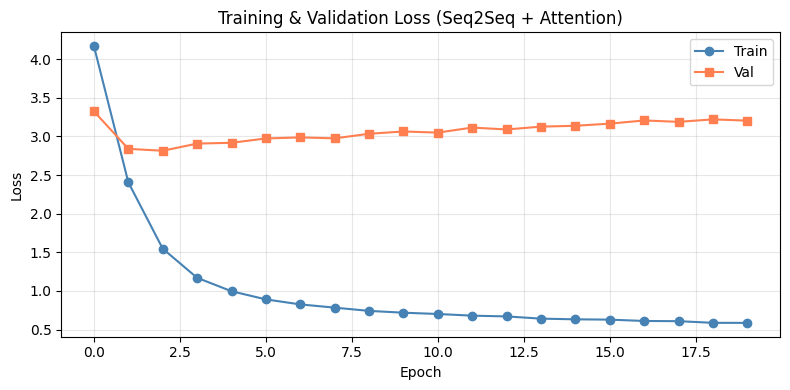

In [6]:
# Training

optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(ignore_index=0)

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    epoch_loss = 0
    for src, trg in loader:
        src, trg = src.to(device), trg.to(device)
        output   = model(src, trg, teacher_forcing_ratio=0.5)
        output   = output[1:].reshape(-1, output.shape[-1])
        trg_flat = trg[1:].reshape(-1)
        loss = criterion(output, trg_flat)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / len(loader)

def evaluate(model, loader, criterion):
    model.eval()
    epoch_loss = 0
    with torch.no_grad():
        for src, trg in loader:
            src, trg = src.to(device), trg.to(device)
            output   = model(src, trg, teacher_forcing_ratio=0.0)
            output   = output[1:].reshape(-1, output.shape[-1])
            trg_flat = trg[1:].reshape(-1)
            loss     = criterion(output, trg_flat)
            epoch_loss += loss.item()
    return epoch_loss / len(loader)

NUM_EPOCHS    = 20
best_val_loss = float("inf")
train_losses, val_losses = [], []

for epoch in range(NUM_EPOCHS):
    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    val_loss   = evaluate(model, val_loader, criterion)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model_attn.pt")
    print(f"Epoch {epoch+1:2d}/{NUM_EPOCHS} | "
          f"Train: {train_loss:.4f} | Val: {val_loss:.4f} | PPL: {np.exp(val_loss):.2f}")

print(f"\nBest Val Loss: {best_val_loss:.4f} | Best PPL: {np.exp(best_val_loss):.2f}")

plt.figure(figsize=(8, 4))
plt.plot(train_losses, marker="o", label="Train", color="steelblue")
plt.plot(val_losses,   marker="s", label="Val",   color="coral")
plt.title("Training & Validation Loss (Seq2Seq + Attention)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# Greedy Translation

model.load_state_dict(torch.load("best_model_attn.pt"))
model.eval()

def greedy_translate(sentence, max_len=50):
    """Translate with greedy decoding; also returns per-step attention weights."""
    model.eval()
    tokens = [en_vocab.word2idx.get(w, 3) for w in clean_en(sentence).split()]
    src    = torch.tensor(tokens, dtype=torch.long).unsqueeze(1).to(device)

    with torch.no_grad():
        encoder_outputs, hidden, cell = model.encoder(src)

    input_token  = torch.tensor([ru_vocab.word2idx["<sos>"]], dtype=torch.long).to(device)
    translated   = []
    attn_weights = []  # collect for visualisation

    with torch.no_grad():
        for _ in range(max_len):
            pred, hidden, cell, attn_w = model.decoder(
                input_token, hidden, cell, encoder_outputs
            )
            attn_weights.append(attn_w.squeeze(0).cpu().numpy())  # [src_len]
            top_token = pred.argmax(1)
            word      = ru_vocab.idx2word[top_token.item()]
            if word == "<eos>":
                break
            translated.append(word)
            input_token = top_token

    return " ".join(translated), attn_weights

print("Greedy translation examples:")
for en, ru in val_pairs[:5]:
    pred, _ = greedy_translate(en)
    print(f"  EN:   {en}")
    print(f"  TRUE: {ru}")
    print(f"  PRED: {pred}")
    print()

Greedy translation examples:
  EN:   tom will sing.
  TRUE: том будет петь.
  PRED: том споёт.

  EN:   i won t lie.
  TRUE: я не буду лгать.
  PRED: я не буду врать.

  EN:   is tom lost?
  TRUE: том потерялся?
  PRED: том заблудился?

  EN:   this is yours.
  TRUE: это ваше.
  PRED: это твоё.

  EN:   please call tom.
  TRUE: позвоните пожалуйста тому.
  PRED: пожалуйста пожалуйста тома.



In [8]:
# BLEU Score from Scratch

def get_ngrams(tokens, n):
    ngrams = defaultdict(int)
    for i in range(len(tokens) - n + 1):
        ngram = tuple(tokens[i:i+n])
        ngrams[ngram] += 1
    return ngrams

def clipped_precision(hypothesis, reference, n):
    hyp_ngrams = get_ngrams(hypothesis, n)
    ref_ngrams = get_ngrams(reference,  n)
    clipped    = 0
    total      = sum(hyp_ngrams.values())
    if total == 0:
        return 0.0
    for ngram, count in hyp_ngrams.items():
        clipped += min(count, ref_ngrams.get(ngram, 0))
    return clipped / total

def brevity_penalty(hypothesis, reference):
    c = len(hypothesis)
    r = len(reference)
    if c > r:
        return 1.0
    return np.exp(1 - r / c) if c > 0 else 0.0

def bleu_score(hypothesis, reference, max_n=4):
    hyp_tokens = hypothesis.split()
    ref_tokens = reference.split()
    if len(hyp_tokens) == 0:
        return 0.0
    log_avg = 0.0
    for n in range(1, max_n + 1):
        cp = clipped_precision(hyp_tokens, ref_tokens, n)
        if cp == 0:
            return 0.0
        log_avg += (1 / max_n) * np.log(cp)
    bp = brevity_penalty(hyp_tokens, ref_tokens)
    return bp * np.exp(log_avg)

# Sanity-check
hyp   = "the match was postponed because of the snow"
ref   = "the match was postponed because it was snowing"
score = bleu_score(hyp, ref)
print(f"Verification BLEU-4: {score:.3f}  (expected ≈ 0.516)")

# Corpus BLEU on validation set
def corpus_bleu(pairs, translate_fn, max_n=4, limit=500):
    scores = [0.0] * max_n
    count  = 0
    for en, ru in pairs[:limit]:
        pred, _ = translate_fn(en)
        for n in range(1, max_n + 1):
            hyp_t = pred.split()
            ref_t = ru.split()
            if len(hyp_t) > 0:
                cp = clipped_precision(hyp_t, ref_t, n)
                bp = brevity_penalty(hyp_t, ref_t)
                scores[n-1] += bp * cp if cp > 0 else 0
        count += 1
    return [s / count for s in scores]

print("\nComputing corpus BLEU on validation set...")
bleu_scores = corpus_bleu(val_pairs, greedy_translate)
print(f"BLEU-1: {bleu_scores[0]:.4f}")
print(f"BLEU-2: {bleu_scores[1]:.4f}")
print(f"BLEU-4: {bleu_scores[3]:.4f}")

Verification BLEU-4: 0.517  (expected ≈ 0.516)

Computing corpus BLEU on validation set...
BLEU-1: 0.4842
BLEU-2: 0.2207
BLEU-4: 0.0226


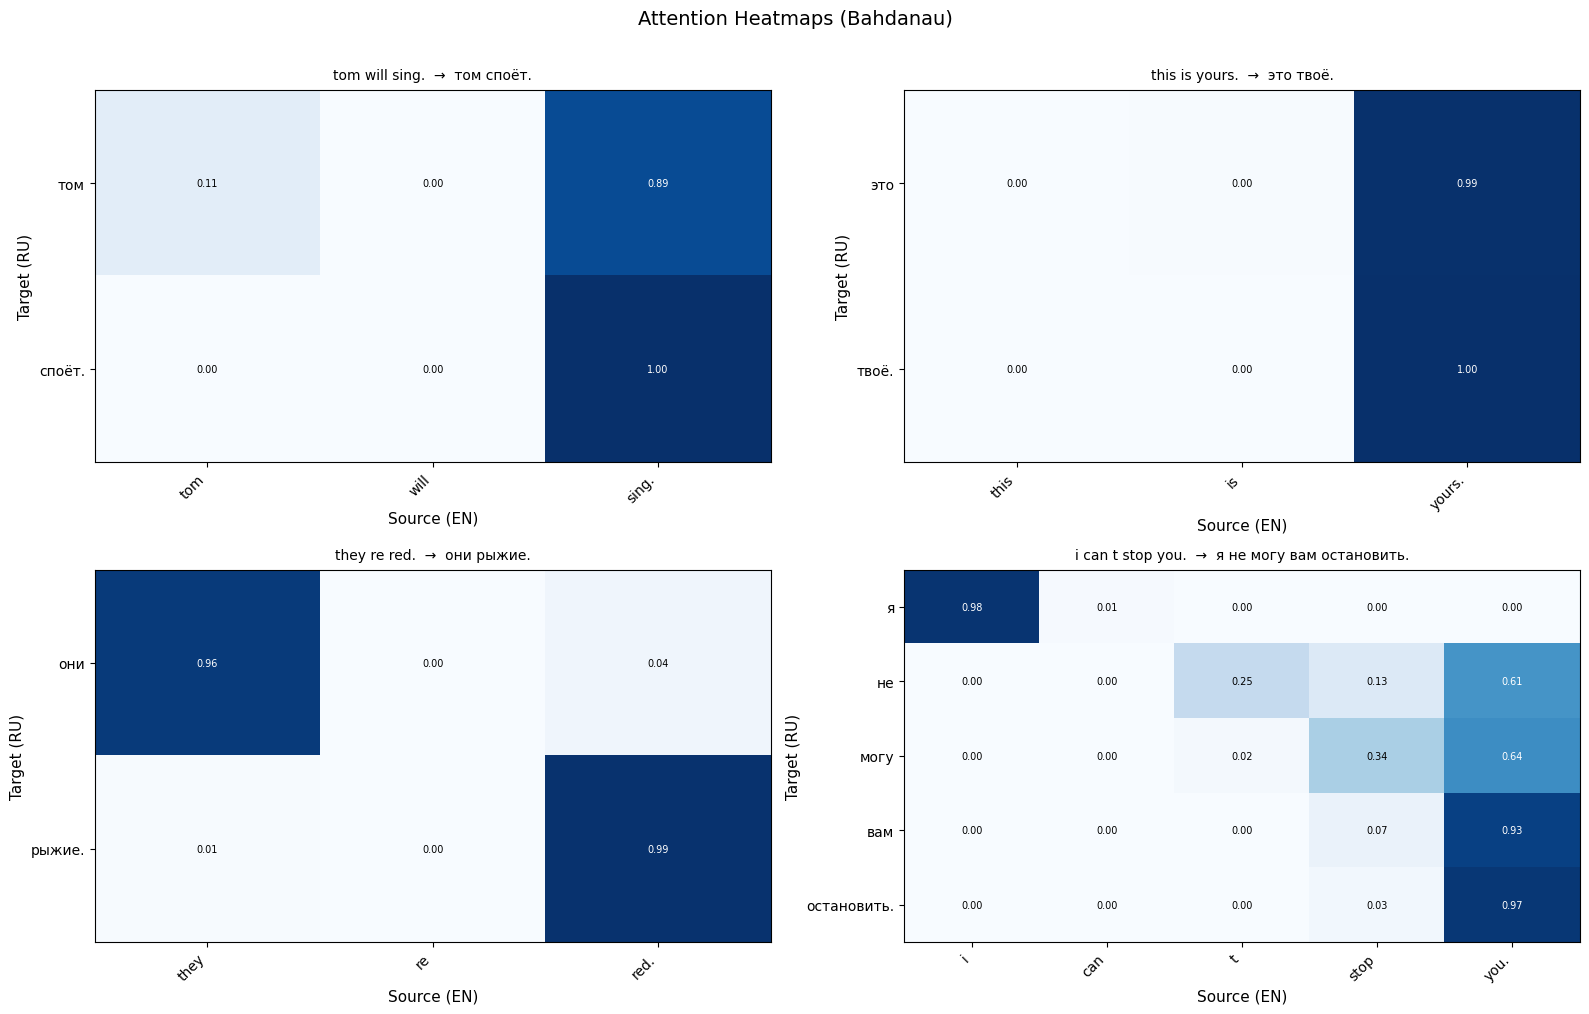


Key observations:
  • Bright diagonal blocks → roughly monotone alignment (typical for close language pairs).
  • Off-diagonal peaks     → reordering captured by the attention mechanism.
  • Each row sums to 1     → probability distribution over source tokens.


In [9]:
# Attention Visualization
#
# For each decoded target token the model assigns a probability distribution
# over all source tokens — the attention weights alpha_{t,s}.
# Plotting this matrix as a heatmap lets us verify that the model has learned
# a meaningful alignment between English source and Russian target words.

def plot_attention(sentence, translation, attn_weights, ax=None):
    """Draw a heatmap of attention weights for one sentence."""
    src_tokens = clean_en(sentence).split()
    trg_tokens = translation.split()

    # attn_weights: list of length trg_len, each element is [src_len]
    attn_matrix = np.array(attn_weights[:len(trg_tokens)])   # [trg_len, src_len]

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(max(5, len(src_tokens)), max(4, len(trg_tokens))))

    im = ax.imshow(attn_matrix, cmap="Blues", aspect="auto", vmin=0, vmax=1)
    ax.set_xticks(range(len(src_tokens)))
    ax.set_xticklabels(src_tokens, rotation=45, ha="right", fontsize=10)
    ax.set_yticks(range(len(trg_tokens)))
    ax.set_yticklabels(trg_tokens, fontsize=10)
    ax.set_xlabel("Source (EN)",  fontsize=11)
    ax.set_ylabel("Target (RU)",  fontsize=11)
    ax.set_title(f"{sentence}  →  {translation}", fontsize=10, pad=8)

    # annotate each cell with its value
    for i in range(len(trg_tokens)):
        for j in range(len(src_tokens)):
            ax.text(j, i, f"{attn_matrix[i, j]:.2f}",
                    ha="center", va="center", fontsize=7,
                    color="white" if attn_matrix[i, j] > 0.5 else "black")

    if standalone:
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        plt.tight_layout()
        plt.show()

# Pick 4 val sentences and visualise side-by-side
viz_sentences = [val_pairs[i][0] for i in [0, 3, 7, 12]]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Attention Heatmaps (Bahdanau)", fontsize=14, y=1.01)

for ax, sentence in zip(axes.flat, viz_sentences):
    pred, attn_w = greedy_translate(sentence)
    plot_attention(sentence, pred, attn_w, ax=ax)

plt.tight_layout()
plt.show()

print("\nKey observations:")
print("  • Bright diagonal blocks → roughly monotone alignment (typical for close language pairs).")
print("  • Off-diagonal peaks     → reordering captured by the attention mechanism.")
print("  • Each row sums to 1     → probability distribution over source tokens.")

In [10]:
# Beam Search Decoding

def beam_search_translate(sentence, beam_width=5, max_len=50):
    model.eval()
    tokens = [en_vocab.word2idx.get(w, 3) for w in clean_en(sentence).split()]
    src    = torch.tensor(tokens, dtype=torch.long).unsqueeze(1).to(device)

    with torch.no_grad():
        encoder_outputs, hidden, cell = model.encoder(src)

    sos_idx = ru_vocab.word2idx["<sos>"]
    eos_idx = ru_vocab.word2idx["<eos>"]

    # beam: (cumulative_log_prob, token_list, hidden, cell)
    beams     = [(0.0, [sos_idx], hidden, cell)]
    completed = []

    with torch.no_grad():
        for _ in range(max_len):
            new_beams = []
            for score, tokens_so_far, h, c in beams:
                input_token = torch.tensor(
                    [tokens_so_far[-1]], dtype=torch.long
                ).to(device)
                pred, new_h, new_c, _ = model.decoder(
                    input_token, h, c, encoder_outputs
                )
                log_probs = torch.log_softmax(pred, dim=1).squeeze(0)

                top_scores, top_indices = log_probs.topk(beam_width)
                for i in range(beam_width):
                    new_score = score + top_scores[i].item()
                    new_token = top_indices[i].item()
                    new_seq   = tokens_so_far + [new_token]
                    if new_token == eos_idx:
                        completed.append((new_score, new_seq))
                    else:
                        new_beams.append((new_score, new_seq, new_h, new_c))

            new_beams.sort(key=lambda x: x[0], reverse=True)
            beams = new_beams[:beam_width]
            if not beams:
                break

    if completed:
        completed.sort(key=lambda x: x[0], reverse=True)
        best_seq = completed[0][1]
    else:
        best_seq = beams[0][1]

    words = [ru_vocab.idx2word.get(t, "<unk>") for t in best_seq[1:]]
    words = [w for w in words if w not in ["<eos>", "<sos>", "<pad>"]]
    return " ".join(words)

In [11]:
# Comparison: Greedy vs Beam Search

print("Running comparison on 100 validation sentences...\n")

results = {}
configs = [
    ("Greedy",   lambda s: greedy_translate(s)[0]),
    ("Beam k=3", lambda s: beam_search_translate(s, beam_width=3)),
    ("Beam k=5", lambda s: beam_search_translate(s, beam_width=5)),
    ("Beam k=10",lambda s: beam_search_translate(s, beam_width=10)),
]

sample = val_pairs[:100]

for name, fn in configs:
    start = time.time()
    preds = [fn(en) for en, ru in sample]
    elapsed  = time.time() - start
    avg_time = elapsed / len(sample)

    bleu4_total = 0
    for (en, ru), pred in zip(sample, preds):
        hyp_t = pred.split()
        ref_t = ru.split()
        if len(hyp_t) > 0:
            cp = clipped_precision(hyp_t, ref_t, 4)
            bp = brevity_penalty(hyp_t, ref_t)
            bleu4_total += bp * cp if cp > 0 else 0

    bleu4 = bleu4_total / len(sample)
    results[name] = {"bleu4": bleu4, "avg_time": avg_time, "preds": preds}
    print(f"{name:<12} | BLEU-4: {bleu4:.4f} | Avg time: {avg_time*1000:.1f}ms/sent")

print("\n" + "="*55)
print(f"{'Method':<12} | {'BLEU-4':>8} | {'Time (ms/sent)':>15}")
print("="*55)
for name, r in results.items():
    print(f"{name:<12} | {r['bleu4']:>8.4f} | {r['avg_time']*1000:>15.1f}")
print("="*55)

Running comparison on 100 validation sentences...

Greedy       | BLEU-4: 0.0100 | Avg time: 6.5ms/sent
Beam k=3     | BLEU-4: 0.0100 | Avg time: 166.2ms/sent
Beam k=5     | BLEU-4: 0.0100 | Avg time: 295.7ms/sent
Beam k=10    | BLEU-4: 0.0100 | Avg time: 677.1ms/sent

Method       |   BLEU-4 |  Time (ms/sent)
Greedy       |   0.0100 |             6.5
Beam k=3     |   0.0100 |           166.2
Beam k=5     |   0.0100 |           295.7
Beam k=10    |   0.0100 |           677.1


In [12]:
# Translation Examples (5 interesting cases)

greedy_preds = results["Greedy"]["preds"]
beam5_preds  = results["Beam k=5"]["preds"]

print("="*70)
print("5 INTERESTING TRANSLATION EXAMPLES")
print("="*70)

indices = [0, 5, 10, 20, 40]

for i in indices:
    en, ru  = sample[i]
    greedy  = greedy_preds[i]
    beam5   = beam5_preds[i]

    g_bleu  = clipped_precision(greedy.split(), ru.split(), 4) * brevity_penalty(greedy.split(), ru.split())
    b_bleu  = clipped_precision(beam5.split(),  ru.split(), 4) * brevity_penalty(beam5.split(),  ru.split())
    winner  = "Beam ✓" if b_bleu >= g_bleu else "Greedy ✓"

    print(f"\nExample {i+1}  [{winner}]")
    print(f"  EN:     {en}")
    print(f"  REF:    {ru}")
    print(f"  Greedy: {greedy}")
    print(f"  Beam-5: {beam5}")

5 INTERESTING TRANSLATION EXAMPLES

Example 1  [Beam ✓]
  EN:     tom will sing.
  REF:    том будет петь.
  Greedy: том споёт.
  Beam-5: том споёт.

Example 6  [Beam ✓]
  EN:     i pay taxes.
  REF:    я плачу налоги.
  Greedy: я плачу что
  Beam-5: я плачу

Example 11  [Beam ✓]
  EN:     that s our job.
  REF:    это наша работа.
  Greedy: это наш работа.
  Beam-5: это наш работа.

Example 21  [Beam ✓]
  EN:     i hate asparagus.
  REF:    я ненавижу спаржу.
  Greedy: я терпеть
  Beam-5: я терпеть

Example 41  [Beam ✓]
  EN:     this is my son.
  REF:    это мой сын.
  Greedy: это мой сын.
  Beam-5: это мой сын.
